# Lesson 101 — Static vs temporal: a graph query cannot read its future

Student edition: complete the three live TODOs before running the experiment.

In [ ]:
# @colab-bootstrap — standalone; no course clone or hidden model import.
# If dependencies are missing, install the pinned versions listed below first.
import sys
print('Python', sys.version.split()[0])

## Runtime — PROVIDED

Tested Python 3.12.3. In a fresh environment install:
```bash
python -m pip install numpy==2.5.0 pandas==3.0.3 scikit-learn==1.9.0 pyarrow==24.0.0
```
Live Colab and a fresh installation are NOT_CHECKED. Code below is entirely inline. The small real task archive is downloaded and verified by SHA-256. The current kernel needs internet only on its first download.

<div class="package-links"><strong>Your deliverable:</strong> a graph query that cannot read its future, a time-respecting split, and a defensible replay of ten published baseline cells.<br><a href="https://avistian.github.io/relational/labs/0101-static-vs-temporal.ipynb">Student notebook</a> · <a href="https://avistian.github.io/relational/labs/solutions/0101-static-vs-temporal.ipynb">Executed solution</a> · <a href="https://avistian.github.io/relational/labs/html/0101-static-vs-temporal.html">Read the lab</a> · <a href="https://avistian.github.io/relational/labs/l101-reproduction.md">Reproduction contract</a></div>

## 1 · Close the notes: retrieve the old boundaries

**Retrieval first:** answer the questions below without notes.

Before reading, write three answers. In L002, why can a correct SQL join still leak? In L055, why can random rows answer a different question from future rows? In L100, why does a sampled context node not automatically receive a label loss?

<details><summary>Feedback — open after trying</summary><p>A join can attach a value learned after prediction time. Random rows can mix historical regimes and future information into training. Context supplies messages; only the chosen seeds supply supervised targets. Today we add a time boundary to all those dependencies.</p></details>

**The tangible win.** Given a typed entity, a prediction time and a horizon, determine which inputs and labels are legal. Work through sections 2–5 first; then implement the three notebook tasks. The full real-data baseline replay is small enough to run in the same session.

This advances the [mission](https://avistian.github.io/relational/MISSION.md): a relational model must earn its score using information that would exist in deployment. [L100](https://avistian.github.io/relational/lessons/0100-heterogeneous-gnn-checkpoint.html) defended identity, sampled dependencies and seed losses on a static graph. It did not test whether every dependency existed at a historical query time. This is the missing boundary before L102's temporal memory models.

## 2 · Static is a task assumption, not a file format

A **static graph task** predicts with one declared graph snapshot. A **temporal task** predicts at a particular time using a permitted history. A file saved today can contain decades of events; reading it as one graph does not make its information historically available.

A random node split can be valid for a declared static, transductive task: the model is allowed to see unlabeled graph structure at evaluation nodes. It is not automatically valid for forecasting. The mistake is using that static information contract while claiming to predict an earlier future.

> **In plain terms.** Hide the answers and also hide the routes through which tomorrow's facts could reveal them.

**Primary reading.** [Fey et al., ICML 2024, sections 3.2–3.3 and Appendix A–B](https://proceedings.mlr.press/v235/fey24a.html) describe relational rows as typed nodes and construct a computation graph for a seed entity and seed time. A **seed** is the entity whose output we want. Its **computation graph** contains the dependencies needed to calculate that output. The temporal neighborhood rule admits neighbor rows whose timestamps do not exceed the seed time.

The course implements that visibility mechanism transparently. We additionally separate event time from arrival time and attach availability to edges. These are explicit deployment-oriented extensions; the paper's single row timestamp does not itself supply versioned business records.

## 3 · Give the query a clock

A query is **(entity, t, Δ)**: the typed entity, the prediction cutoff `t`, and a future horizon `Δ`. Its input uses history through `t`. Its target describes the interval **(t, t + Δ]**. The left endpoint is excluded; the right endpoint is included.

**Worked example.** At day 5, predict purchases during days greater than 5 and at most 8. A purchase at exactly day 5 can be an input under our inclusive observation convention. It is not part of that future target. If production predicts at the beginning of a day, same-day events may not be known: define a finer timestamp or use a strict boundary. Never silently swap conventions.

Two clocks matter. **Event time** says when the event happened. **Availability time** says when the predictor could first access the record. A correction may refer to day 4 but arrive on day 7. A day-5 predictor cannot use it.

**Commit before reading:** may a day-5 query use a day-4 record that arrived on day 7? Explain your rule.

The row predicate is:

```python
(event_time <= query_time) and (available_time <= query_time)
```

Changing only the cutoff should change the visible inputs, not the records themselves. Predict the legal and event-only means at day 5 before moving the control.

| Record | Event day | Arrival day | Value | Legal at day 5? |
|---|---:|---:|---:|---|
| Past purchase | 3 | 3 | 2 | Yes |
| Late correction | 4 | 7 | 8 | No |
| Boundary purchase | 5 | 5 | 4 | Yes |
| Future outcome | 8 | 8 | 10 | No |

**Worked trace.** At day 5, the legal values are 2 and 4: mean 3. Event-only filtering also includes the late correction of 8: mean 14/3. Reading all stored rows additionally includes the future outcome of 10: mean 6. These are illustrative values, not measured paper results.

**Feature versions.** An old customer row can contain a balance updated yesterday. Checking the customer's creation date does not make the current balance legal for a query last year. Use the version available at the query time. Likewise, an undated entity table is safe only for attributes genuinely treated as timeless under the task contract.

## 4 · Carry the same clock through every graph hop

An edge is a directed connection from a source row to a receiving row. A **hop** expands one layer of incoming neighbors. Two message-passing layers can consume a fact two edges away. Filtering only direct neighbors leaves that second route open.

<figure class="temporal-figure" tabindex="0">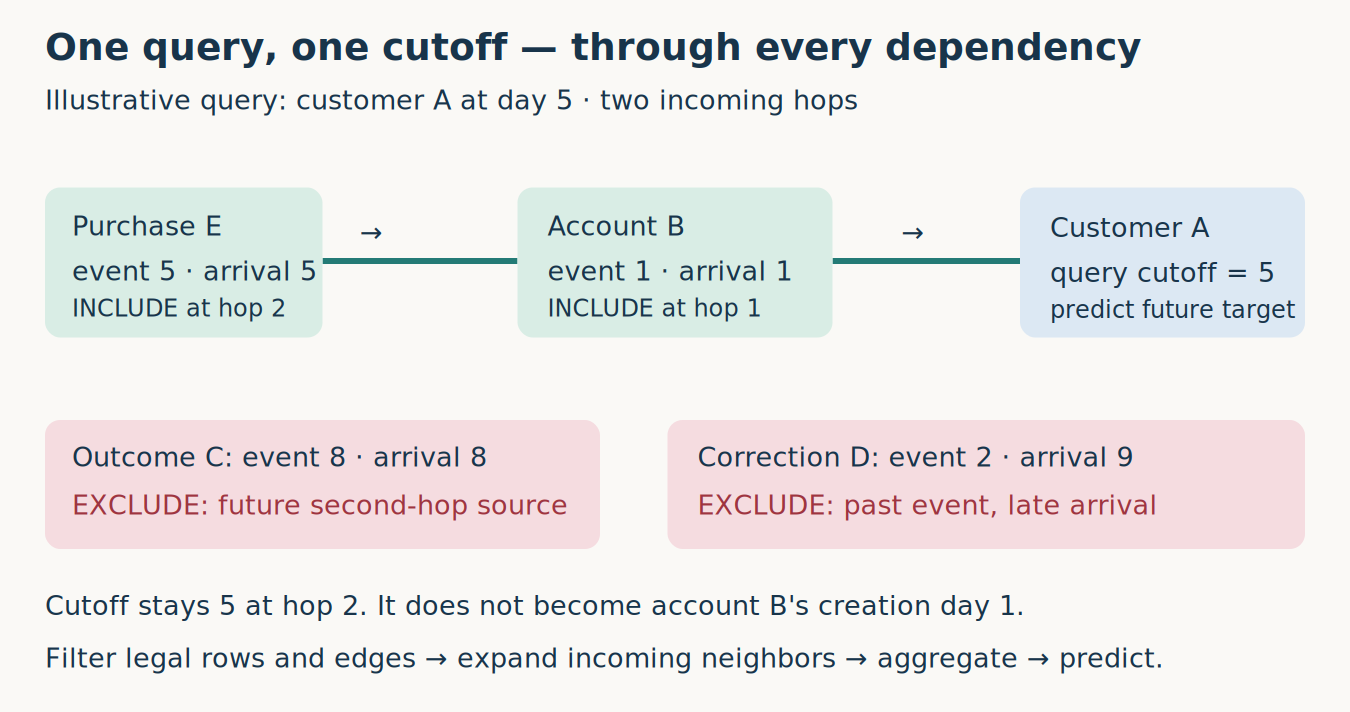<figcaption>Illustrative computation. At query day 5, two-hop inputs include A, B and E; future C and late-arriving D are excluded.</figcaption></figure>

The notebook's `incoming_subgraph` receives node times, edge availability times, a seed, a query cutoff and a depth. At each hop it checks both endpoint rows and the edge, then expands the admitted sources. The output retains original edge indices, including parallel edges. A depth of zero retains the seed alone.

**Worked trace.** A and B existed before day 5. C connects into B but occurs on day 8. D also connects into B, with an old event date but day-9 arrival. E connects into B and is available on day 5. A two-hop query for A at day 5 includes A, B and E. At day 9 it can include all five nodes.

**One cutoff, several hops.** Keep the original query time at every hop. Replacing it with B's creation day 1 would incorrectly discard E, although E was available when the prediction was requested. A walk with monotonically decreasing event times is a different temporal mechanism. Do not infer it from a rule that merely requires each dependency to predate the query.

**One entity, several queries.** `(customer A, day 5)` and `(customer A, day 9)` need different neighborhoods. Do not share a cached embedding keyed only by entity ID. A cache key must capture the cutoff, model state and other computation dependencies. This extends L098's distinct seed-query principle.

**Filter before sampling.** A finite neighbor budget should choose among legal neighbors. Sampling from the entire graph and then dropping future records can leave too few historical neighbors and changes the sampling distribution. Our transparent audit uses all legal neighbors; it verifies visibility rather than a specific finite-fanout distribution.

> **Source-reading check.** Fey's printed Algorithm 1 filters `τ(v)` while describing candidate edges `(w,v)`; Appendix A's temporal-neighborhood equation filters the neighbor `τ(w)`. We follow the neighbor equation and the surrounding availability explanation. A literal receiver-only filter would admit future sources. The code makes this distinction testable.

## 5 · Split target queries, then audit label maturity

A **label window** is the future interval used to construct an answer. **Label maturity** is the time when its full answer can be known. With no reporting delay it is `t + Δ`; delayed outcomes mature later. Training may use labels that are in the future relative to their own historical query, provided they are known when the model is fitted. Inputs for that query must still stop at its query time.

<figure class="temporal-figure" tabindex="0">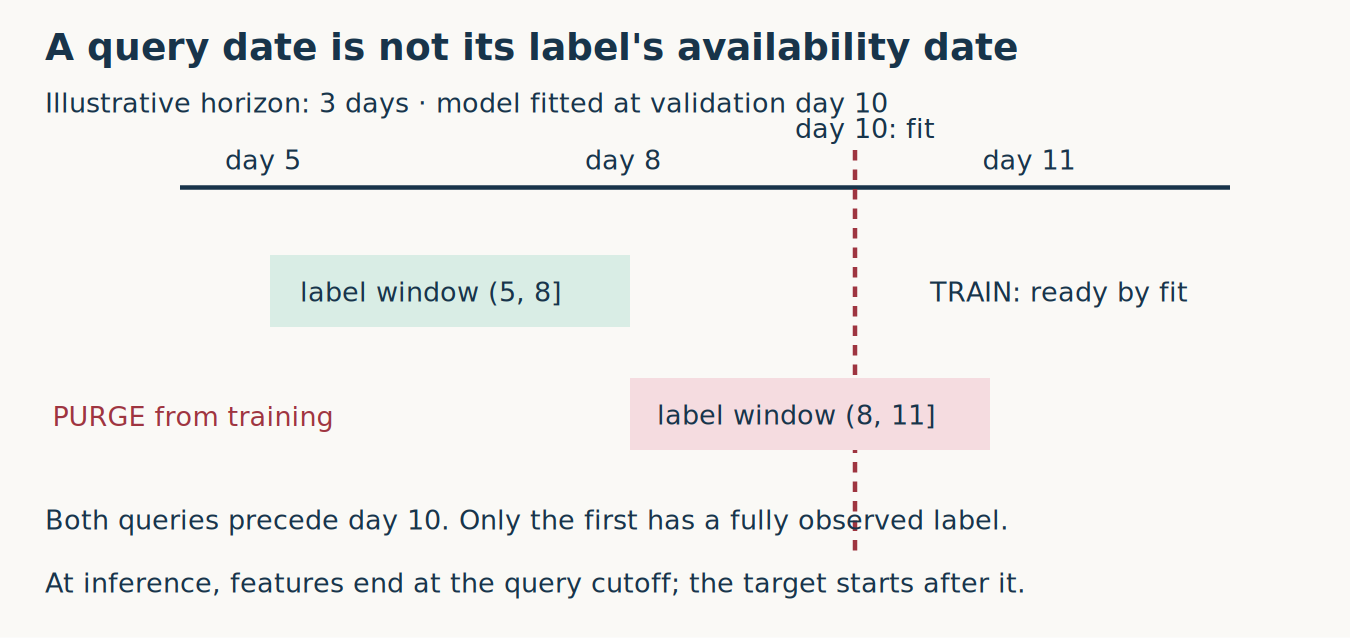<figcaption>Illustrative computation. A label window ending at day 8 can train a day-10 model; a window ending at day 11 cannot.</figcaption></figure>

**Worked example.** Fit a model on day 10. A day-5 query with a three-day horizon has a label by day 8 and can train it. A day-8 query ends on day 11, so it cannot train that day-10 model. Both query dates precede the split, but only one label is ready.

The lab's explicit split policy is:

| Query region | Additional condition | Role |
|---|---|---|
| `t < validation_time` | label ready by validation time | Train |
| `validation_time ≤ t < test_time` | label ready by test time | Validation |
| `t ≥ test_time` | retained for later offline scoring | Test |
| Earlier region but label not ready | crosses the next boundary | Purged |

**Purging** removes examples whose label windows cross a fitting boundary. This is a conservative declared course policy, not a universal rule that every validation query must be purged. The important contract is that the labels used for a decision existed at that decision's time. Our test fixture has complete outcomes; a live system must also handle right-censored labels whose horizon has not finished.

A random split can place day-500 labels into the fitting set of a model evaluated at day 100. The lab counts such forbidden training-label/test-query pairs separately. Random and chronological partitions contain different evaluation examples; their accuracy difference alone would not isolate leakage.

**Four independent gates.** Audit target split and label maturity; row/edge availability at every hop; feature versions and preprocessing fit scope; and model selection before test scoring. Sorting target rows repairs only the first of these. In particular, vocabulary building or imputation on future records can leak even after graph filtering passes.

## 6 · Make a leakage failure observable

The synthetic experiment intentionally creates a future-answer channel. Each of 600 queries has an independent binary label. Its only legitimate historical value is zero. A late-arriving record and a future outcome record both carry that label. This is an adversarial test fixture, not a simulation of ordinary customer behavior.

Three fixed feature rules feed the same one-dimensional logistic regression. Logistic regression learns a weight and intercept and turns their weighted input into a binary probability. Legal filtering sees zero. Event-only filtering sees `y/2`. Static filtering sees `2y/3`. The latter two directly encode the answer.

The chronological training, validation and test sets are identical across arms. Two crossing-window queries are purged, leaving 359 training, 119 validation and 120 test examples. We run all three arms for seeds 0, 1 and 2, with fixed `C=1`, no hyperparameter search and no test-driven selection. Seeds alter the independent labels. They are not different real-world datasets.

| Seed | Legal accuracy | Event-only accuracy | Static accuracy |
|---|---:|---:|---:|
| 0 | 50.00% | 100.00% | 100.00% |
| 1 | 45.00% | 100.00% | 100.00% |
| 2 | 38.33% | 100.00% | 100.00% |

**Measured author-reference results:** all nine fits completed; synthetic diagnostic, not a paper score.

The legal arm cannot infer an independent future label from a constant. Its accuracy varies with the sampled test class balance and the fitted training majority; a finite test score need not equal 50%. The perfect leaky scores diagnose a constructed answer channel. They establish no typical uplift from graph structure or temporal modeling.

The separate graph audit checks 32 generated graphs at three cutoffs and four depths: **384 cases**. It compares the Python traversal against independently filtered SQL edges, including cycles, parallel edges, boundary timestamps and unavailable endpoints. The named two-hop fixture catches future sources behind legal first-hop nodes.

## 7 · Reproduce a complete, named published result

The foundational temporal-graph idea comes from Fey et al. The quantitative target here comes from the later [Robinson et al. RelBench paper, version 1, Table 4](https://arxiv.org/html/2407.20060v1#S5.T4): **all five heuristic baseline columns for `rel-f1 / driver-position`, on both validation and test**. This is a complete selected baseline slice, not the full paper.

The target is each driver's average finishing position over the next **60 days**. Lower is better for **mean absolute error (MAE)**: average `abs(prediction − target)`, measured in finishing-position units. We read every row of the released task: 7,453 train, 499 validation and 760 test queries. No subsampling or randomized split occurs.

**Follow the actual source.** [Pinned `baseline_node.py`](https://github.com/stanford-star/relbench/blob/9aa346267c2e1c560bd92da07d6f4ad1ca2f0639/examples/baseline_node.py) uses training labels for validation predictions, then **train plus validation labels for test predictions**. This is permitted here because their full 60-day windows end by the test cutoff. We assert both boundaries. Reporting “train-only test fit” would misdescribe this release.

| Baseline | Computation from the permitted fitting labels |
|---|---|
| Global zero | Predict 0 for every query |
| Global mean | Predict the overall label mean |
| Global median | Predict the overall label median |
| Entity mean | Predict the driver's historical label mean; unseen driver → 0 |
| Entity median | Predict the driver's historical label median; unseen driver → 0 |

The zero fallback is part of the released protocol, even though it is a poor finishing-position estimate. Changing it is an extension and needs a separate result. The program passes only entity ID and date to prediction functions; scoring reads labels afterward. There is no optimizer, architecture, initialization, checkpoint selection or stochastic training to reconstruct for these deterministic methods.

| Method | Validation MAE / paper | Test MAE / paper | Verdict |
|---|---:|---:|---|
| global_zero | 11.083200 / 11.083 | 11.926206 / 11.926 | MATCH |
| global_mean | 4.334385 / 4.334 | 4.512881 / 4.513 | MATCH |
| global_median | 4.135571 / 4.136 | 4.399101 / 4.399 | MATCH |
| entity_mean | 7.181002 / 7.181 | 8.501358 / 8.501 | MATCH |
| entity_median | 7.114262 / 7.114 | 8.518509 / 8.519 | MATCH |


All ten cells match the paper's three-decimal values within a declared **0.0005 rounding tolerance**. Every prediction vector also agrees with the unmodified released baseline function within `1e-12`. The archive's SHA-256 matches the checksum in release v1.1.0. Saved predictions preserve query IDs, dates, targets and original order.

> **Scope check.** `MATCH` describes those ten rounded score cells. Exact historical execution identity remains `NOT_ESTABLISHED`: the pinned release is a reproducible reference, not proof of the authors' exact run environment. The LightGBM and RDL columns, other tasks, and regeneration of targets from the original relational database are **NOT_RUN** here. Full-paper reproduction is **NOT_ESTABLISHED**. Matching heuristics does not establish temporal GNN correctness or superiority.

This is also an instructive negative result for a simplistic relational story: the per-entity heuristics are worse than global mean/median on this task. Remember their zero fallback and distribution shift before attributing the gap. Neither this baseline slice nor our fabricated leakage experiment tests the mission's full learned-relational-model thesis.

## 8 · Lab, reproduction commands and defense

Implement `available`, `split_queries` and `incoming_subgraph`. CHECK cells confront boundary equality, delayed availability, immature labels, second-hop leakage and repeated queries for one seed. The solution includes all visible functions, the nine-fit diagnostic and the complete real-data replay. It requires no course imports and downloads only a checksum-verified task archive.

From the repository root:

```bash
.venv/bin/python labs/_check_l101.py
OMP_NUM_THREADS=1 .venv/bin/python labs/_verify_l101.py
.venv/bin/python labs/_build_l101.py
.venv/bin/python labs/_execute_l101.py
.venv/bin/python labs/_delivery_l101.py
```

The [contract](https://avistian.github.io/relational/labs/l101-reproduction.md) pins sources, data, environment, commands and remaining gaps. The [reference card](https://avistian.github.io/relational/reference/temporal-visibility.html) condenses the availability and split rules.

**EXIT — hand in an argument, not just a green cell.** Submit your three implementations and fresh experiment output. Trace A at day 5 and day 9. Explain why an old event can still be unavailable. Derive why the day-8/day-11 label must be purged before a day-10 fit. Identify the actual fitting rows behind the paper's test mean baseline. Finally, write two separate claims: one justified by the ten score matches, and one the evidence cannot support.

Rubric: 0–2 each for clocks, multi-hop dependencies, label maturity, reproducible execution and claim boundaries; pass requires 8/10 with no zero in the first three. Prepared material is not evidence of your mastery: **PENDING_WRITTEN_DEFENSE**.

Ask the agent follow-up questions about any unclear step, or paste your EXIT for a strict defense. Tomorrow, reconstruct the late-arrival example from memory. In a week, distinguish query time from model-fit time again. Next, [L102 in the roadmap](https://avistian.github.io/relational/plan/year-3.md) introduces memory updated by events; update-before-predict ordering must obey the same information boundary.


## Implement the information contract

The three TODO functions below are the live functions called by the experiment and traversal. A raised error means the task is unfinished; do not skip its CHECK.

In [ ]:
import hashlib

import io

import json

import urllib.request

import zipfile

from pathlib import Path

import numpy as np

import pandas as pd

from sklearn.linear_model import LogisticRegression

TASK_URL='https://relbench.stanford.edu/download/rel-f1/tasks/driver-position.zip'

TASK_SHA256='775b28a51604169539bbe712a2f0d15158c112bc6abf316cdd0995087a7ae03e'

ARMS=['global_zero','global_mean','global_median','entity_mean','entity_median']

TARGETS={'val':[11.083,4.334,4.136,7.181,7.114], 'test':[11.926,4.513,4.399,8.501,8.519]}

### TODO · `available`

Inclusive observation convention: both occurrence and arrival must be known.

In [ ]:
def available(event_time, available_time, query_time):
    # TODO: implement the stated contract; preserve the function signature.
    raise NotImplementedError('available')

### CHECK — run without editing

In [ ]:
assert available(4,7,5) is False
assert available(5,5,5) is True
assert available(6,4,5) is False
print('PASS: arrival, event and equality boundaries')

### TODO · `split_queries`

Purge labels that mature beyond the next fit/evaluation boundary.

In [ ]:
def split_queries(queries, val_time, test_time):
    # TODO: implement the stated contract; preserve the function signature.
    raise NotImplementedError('split_queries')

### CHECK — run without editing

In [ ]:
queries=[{'time':t,'label_ready':t+3} for t in [5,8,10,17,20]]
assert split_queries(queries,10,20)==['train','purged','val','val','test']
print('PASS: maturity and split boundary placement')

### TODO · `incoming_subgraph`

All-neighbor incoming expansion; keep the SAME query cutoff at every hop.

nodes maps typed IDs to (event_time, available_time).
edges stores (source, destination, edge_available_time).
The returned edge indices refer to the original edge list, including duplicates.
This is a visibility audit, not a trained GNN or a temporal-walk model.

In [ ]:
def incoming_subgraph(nodes, edges, seed, query_time, depth):
    # TODO: implement the stated contract; preserve the function signature.
    raise NotImplementedError('incoming_subgraph')

### CHECK — run without editing

In [ ]:
nodes={'a':(0,0),'b':(1,1),'c':(8,8),'d':(2,9),'e':(5,5)}
edges=[('b','a',1),('c','b',8),('d','b',2),('e','b',5)]
assert incoming_subgraph(nodes,edges,'a',5,2)==({'a','b','e'},{0,3})
assert incoming_subgraph(nodes,edges,'a',9,2)==(set(nodes),set(range(4)))
assert incoming_subgraph(nodes,edges,'a',5,0)==({'a'},set())
print('PASS: all hops and distinct query times')

### PROVIDED · `load_task`

Read all three released tables after validating the release archive hash.

In [ ]:
def load_task(cache_dir):
    """Read all three released tables after validating the release archive hash."""
    cache_dir=Path(cache_dir);cache_dir.mkdir(parents=True,exist_ok=True)
    path=cache_dir/'driver-position.zip'
    if not path.exists():
        with urllib.request.urlopen(TASK_URL,timeout=60) as response:
            raw=response.read()
        if hashlib.sha256(raw).hexdigest()!=TASK_SHA256:
            raise ValueError('Downloaded task bytes differ from v1.1.0')
        path.write_bytes(raw)
    raw=path.read_bytes()
    if hashlib.sha256(raw).hexdigest()!=TASK_SHA256:
        raise ValueError('Cached task bytes differ from v1.1.0')
    with zipfile.ZipFile(io.BytesIO(raw)) as archive:
        return {s:pd.read_parquet(io.BytesIO(archive.read(f'driver-position/{s}.parquet'))) for s in ['train','val','test']}

### PROVIDED · `baseline_predict`

Fit only on permitted labels. Query tables need only driverId and date.

Entity baselines use zero for an unseen driver, matching the pinned release.
No optimizer, stochastic initialization, feature preprocessing or tuning occurs.

In [ ]:
def baseline_predict(fit_table, query_table, arm):
    """Fit only on permitted labels. Query tables need only driverId and date.

    Entity baselines use zero for an unseen driver, matching the pinned release.
    No optimizer, stochastic initialization, feature preprocessing or tuning occurs.
    """
    if arm=='global_zero':
        return np.zeros(len(query_table))
    if arm=='global_mean':
        return np.full(len(query_table),fit_table.position.mean())
    if arm=='global_median':
        return np.full(len(query_table),fit_table.position.median())
    if arm in ['entity_mean','entity_median']:
        values=fit_table.groupby('driverId').position.agg(arm.split('_')[1])
        return query_table.driverId.map(values).fillna(0).to_numpy(dtype=float)
    raise ValueError(arm)

### PROVIDED · `paper_replay`

Full five-baseline, two-split published target; fixed rounding tolerance .0005.

In [ ]:
def paper_replay(cache_dir, prediction_path=None):
    """Full five-baseline, two-split published target; fixed rounding tolerance .0005."""
    tables=load_task(cache_dir)
    val_time=pd.Timestamp('2005-01-01');test_time=pd.Timestamp('2010-01-01')
    horizon=pd.Timedelta(days=60)
    assert (tables['train'].date+horizon<=val_time).all()
    assert (tables['val'].date>=val_time).all()
    assert (tables['val'].date+horizon<=test_time).all()
    assert (tables['test'].date>=test_time).all()
    records=[];predictions={}
    for split in ['val','test']:
        # The released baseline_node.py explicitly refits on train+val for test.
        fit=tables['train'] if split=='val' else pd.concat([tables['train'],tables['val']],ignore_index=True)
        queries=tables[split][['driverId','date']].copy()
        for i,arm in enumerate(ARMS):
            pred=baseline_predict(fit,queries,arm)
            truth=tables[split].position.to_numpy()
            mae=float(np.abs(pred-truth).mean())
            target=TARGETS[split][i]
            records.append({'split':split,'arm':arm,'fit_rows':len(fit),'evaluation_rows':len(queries),'mae':mae,'paper_mae':target,'absolute_gap':abs(mae-target),'verdict':'MATCH' if abs(mae-target)<=.0005 else 'FAIL'})
            predictions[f'{split}_{arm}']=pred
        predictions[f'{split}_target']=tables[split].position.to_numpy()
        predictions[f'{split}_driverId']=queries.driverId.to_numpy()
        predictions[f'{split}_date_ns']=queries.date.to_numpy(dtype='datetime64[ns]').astype('int64')
    if prediction_path:
        np.savez_compressed(prediction_path,**predictions)
    return {'status':'COMPLETE','target':'Robinson et al. arXiv:2407.20060v1 Table 4, rel-f1/driver-position, all five heuristic columns',
            'source_commit':'9aa346267c2e1c560bd92da07d6f4ad1ca2f0639','data_sha256':TASK_SHA256,
            'counts':{s:len(t) for s,t in tables.items()},'seed_policy':'deterministic; repetitions would duplicate predictions',
            'tolerance':.0005,'results':records,'historical_execution_identity':'NOT_ESTABLISHED','full_paper_reproduction':'NOT_ESTABLISHED',
            'unrun':['LightGBM and RDL columns','other tasks and databases','reconstruction of task labels from original database']}

### PROVIDED · `course_experiment`

Nine fresh fits: a deliberately constructed future-information witness.

Each query has one known zero-valued past record, a late-arriving record
carrying its label, and a future outcome record carrying the same label.
Independent Bernoulli labels ensure there is no legitimate past signal.
This is a diagnostic construction, not an estimate of typical leakage uplift.

In [ ]:
def course_experiment():
    """Nine fresh fits: a deliberately constructed future-information witness.

    Each query has one known zero-valued past record, a late-arriving record
    carrying its label, and a future outcome record carrying the same label.
    Independent Bernoulli labels ensure there is no legitimate past signal.
    This is a diagnostic construction, not an estimate of typical leakage uplift.
    """
    records=[];split_audit=[]
    for seed in [0,1,2]:
        rng=np.random.default_rng(seed);n=600
        times=np.arange(n);y=rng.integers(0,2,n)
        queries=[{'time':int(t),'label_ready':int(t+2)} for t in times]
        tags=np.array(split_queries(queries,360,480))
        train=np.where(tags=='train')[0];val=np.where(tags=='val')[0];test=np.where(tags=='test')[0]
        # Audit a random partition separately. It changes evaluation samples.
        perm=rng.permutation(n);random_train=perm[:360];random_test=perm[480:]
        bad_pairs=sum(queries[i]['label_ready']>queries[j]['time'] for i in random_train for j in random_test)
        split_audit.append({'seed':seed,'random_future_label_pairs':int(bad_pairs),'random_pairs':len(random_train)*len(random_test),'chronological_future_label_pairs':0,'purged':int(sum(tags=='purged'))})
        features={arm:[] for arm in ['legal','event_only','static']}
        for t,label in zip(times,y):
            events=[(int(t-1),int(t-1),0.),(int(t-1),int(t+1),float(label)),(int(t+1),int(t+1),float(label))]
            features['legal'].append(np.mean([v for e,a,v in events if available(e,a,int(t))]))
            features['event_only'].append(np.mean([v for e,a,v in events if e<=t]))
            features['static'].append(np.mean([v for e,a,v in events]))
        for arm,values in features.items():
            x=np.asarray(values).reshape(-1,1)
            model=LogisticRegression(C=1,solver='lbfgs',max_iter=200,random_state=seed).fit(x[train],y[train])
            records.append({'seed':seed,'arm':arm,'train':len(train),'val':len(val),'test':len(test),
                            'val_accuracy':float(model.score(x[val],y[val])),'test_accuracy':float(model.score(x[test],y[test])),
                            'coefficient':float(model.coef_[0,0]),'intercept':float(model.intercept_[0]),
                            'test_predictions':model.predict(x[test]).tolist(),'test_labels':y[test].tolist()})
    return {'status':'COMPLETE','fits':9,'records':records,'split_audit':split_audit,'paper_comparison':'INCOMPARABLE','claim':'Constructed leakage witness; not a real-world performance estimate'}

## Run the complete course diagnostic — PROVIDED

Predict all three outcomes before running. These are new kernel results, separate from the author-reference table.

In [ ]:
fresh_course=course_experiment()
display(pd.DataFrame(fresh_course['records']).drop(columns=['test_predictions','test_labels']))
display(pd.DataFrame(fresh_course['split_audit']))

## Full selected paper slice — PROVIDED

All five heuristic baselines, complete validation and test tables. No subsampling. This is not the full GNN benchmark. `MATCH` applies only to the ten printed MAE cells.

In [ ]:
fresh_paper=paper_replay(Path('l101-cache'),Path('l101-predictions.npz'))
display(pd.DataFrame(fresh_paper['results']))
assert all(r['verdict']=='MATCH' for r in fresh_paper['results'])
Path('l101-fresh-evidence.json').write_text(json.dumps({'paper':fresh_paper,'course':fresh_course},indent=2))
print('Full selected slice:',fresh_paper['status'],'| Full paper:',fresh_paper['full_paper_reproduction'])

## EXIT TICKET

Submit the implementations, fresh JSON and the five-part defense from section 8. Explain one future path, one late record, one immature label, the train+validation test fit and the exact scope of MATCH.

**PENDING_WRITTEN_DEFENSE** — running prepared code alone does not establish mastery.